<a href="https://colab.research.google.com/github/warish6798/Delhi-vector-data-analysis/blob/main/LST_ahsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

data_path = '/content/drive/MyDrive/GEE/'

print("Files found:")
for f in os.listdir(data_path):
    print(f)


Files found:
earthengine
Aurooj
AHSIS_Paper
LST_winter_2000.tif
LST_summer_2015.tif
LST_summer_2025.tif
LST_summer_2000.tif
LST_winter_2015.tif
LST_winter_2025.tif
LST_summary_summer_winter.xlsx
LST_maps_summer_winter.png
LST_maps_summer_winter.pdf


In [ ]:
import rasterio
import numpy as np

def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        arr[arr == nodata] = np.nan
        meta = src.meta
    return arr, meta

# Load correct file (change as needed)
lst15, meta = load_raster(data_path + 'LST_summer_2015.tif')

print("Shape:", lst15.shape)
print("CRS:", meta['crs'])
print("Resolution:", meta['transform'].a, "x", abs(meta['transform'].e))
print("NoData value:", meta['nodata'])


Shape: (1779, 1888)
CRS: EPSG:4326
Resolution: 0.00026949458523585647 x 0.00026949458523585647
NoData value: None


In [ ]:
# Load all rasters we need
lst25_w = load_raster(data_path + 'LST_winter_2025.tif')[0]
lst25_s = load_raster(data_path + 'LST_summer_2025.tif')[0]

lst15_s = load_raster(data_path + 'LST_summer_2015.tif')[0]
lst15_w = load_raster(data_path + 'LST_winter_2015.tif')[0]

lst00_s = load_raster(data_path + 'LST_summer_2000.tif')[0]
lst00_w = load_raster(data_path + 'LST_winter_2000.tif')[0]

print("All rasters loaded successfully!")



All rasters loaded successfully!


In [ ]:
import glob
import os

# get all LST files in the folder
lst_files = sorted(glob.glob(os.path.join(data_path, "LST_*.tif")))

print("Shapes of all LST rasters:\n")

for f in lst_files:
    arr, _ = load_raster(f)
    print(os.path.basename(f), "→", arr.shape)


Shapes of all LST rasters:

LST_summer_2000.tif → (1779, 1888)
LST_summer_2015.tif → (1779, 1888)
LST_summer_2025.tif → (1779, 1888)
LST_winter_2000.tif → (1779, 1888)
LST_winter_2015.tif → (1779, 1888)
LST_winter_2025.tif → (1779, 1888)


In [ ]:
import glob
import os
import pandas as pd
import numpy as np

# get all LST files
lst_files = sorted(glob.glob(os.path.join(data_path, "LST_*.tif")))

records = []

for f in lst_files:
    arr, _ = load_raster(f)

    lst_min = np.nanmin(arr)
    lst_max = np.nanmax(arr)
    lst_mean = np.nanmean(arr)
    lst_std = np.nanstd(arr)

    records.append({
        "filename": os.path.basename(f),
        "min_LST": lst_min,
        "max_LST": lst_max,
        "mean_LST": lst_mean,
        "std_LST": lst_std
    })

df = pd.DataFrame(records)

# Split into Summer and Winter based on filename
df_summer = df[df["filename"].str.contains("summer", case=False)]
df_winter = df[df["filename"].str.contains("winter", case=False)]

# Save to Excel with two sheets
xlsx_path = os.path.join(data_path, "LST_summary_summer_winter.xlsx")

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_summer.to_excel(writer, sheet_name="Summer", index=False)
    df_winter.to_excel(writer, sheet_name="Winter", index=False)

print("Saved Excel file:", xlsx_path)
print("\nSummer files:")
print(df_summer)
print("\nWinter files:")
print(df_winter)


Saved Excel file: /content/drive/MyDrive/GEE/LST_summary_summer_winter.xlsx

Summer files:
              filename    min_LST    max_LST   mean_LST   std_LST
0  LST_summer_2000.tif  27.519526  45.892347  38.392633  1.984141
1  LST_summer_2015.tif  28.747490  49.997428  41.159415  2.385041
2  LST_summer_2025.tif  21.209899  49.999648  40.561041  2.425008

Winter files:
              filename    min_LST    max_LST   mean_LST   std_LST
3  LST_winter_2000.tif   5.756878  38.666873  20.592483  1.616728
4  LST_winter_2015.tif  17.533631  31.472899  23.336810  1.860842
5  LST_winter_2025.tif  15.566045  33.491079  23.028904  1.610931


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xlsx_path = os.path.join(data_path, "LST_summary_summer_winter.xlsx")

summer = pd.read_excel(xlsx_path, sheet_name="Summer")
winter = pd.read_excel(xlsx_path, sheet_name="Winter")


In [ ]:
summer["year"] = summer["filename"].str.extract(r'(\d{4})').astype(int)
winter["year"] = winter["filename"].str.extract(r'(\d{4})').astype(int)

summer = summer.sort_values("year")
winter = winter.sort_values("year")


In [ ]:
# Fit linear regression (y = mx + c)
m_s, c_s = np.polyfit(summer["year"], summer["mean_LST"], 1)
m_w, c_w = np.polyfit(winter["year"], winter["mean_LST"], 1)

# Create smooth trend lines
years_smooth = np.linspace(summer["year"].min(), summer["year"].max(), 100)
trend_summer = m_s * years_smooth + c_s
trend_winter = m_w * years_smooth + c_w


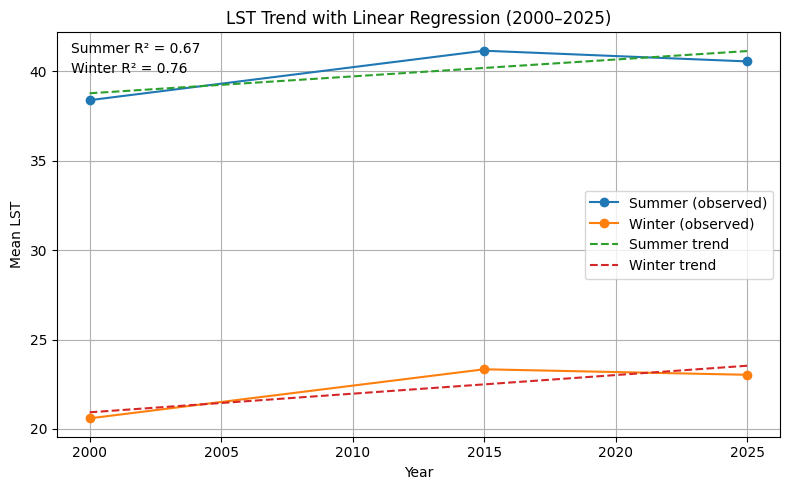

In [ ]:
plt.figure(figsize=(8,5))

# Actual data points
plt.plot(summer["year"], summer["mean_LST"], marker="o", label="Summer (observed)")
plt.plot(winter["year"], winter["mean_LST"], marker="o", label="Winter (observed)")

# Trend lines
plt.plot(years_smooth, trend_summer, linestyle="--", label="Summer trend")
plt.plot(years_smooth, trend_winter, linestyle="--", label="Winter trend")
from sklearn.metrics import r2_score

# R² values
r2_summer = r2_score(summer["mean_LST"], m_s * summer["year"] + c_s)
r2_winter = r2_score(winter["mean_LST"], m_w * winter["year"] + c_w)

# Add R² text on plot
plt.text(0.02, 0.95, f"Summer R² = {r2_summer:.2f}",
         transform=plt.gca().transAxes, fontsize=10)

plt.text(0.02, 0.90, f"Winter R² = {r2_winter:.2f}",
         transform=plt.gca().transAxes, fontsize=10)

plt.xlabel("Year")
plt.ylabel("Mean LST")
plt.title("LST Trend with Linear Regression (2000–2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Summer trend: {m_s:.3f} °C per year")
print(f"Winter trend: {m_w:.3f} °C per year")


Summer trend: 0.094 °C per year
Winter trend: 0.104 °C per year


Saved:
/content/drive/MyDrive/GEE/LST_maps_summer_winter.png
/content/drive/MyDrive/GEE/LST_maps_summer_winter.pdf


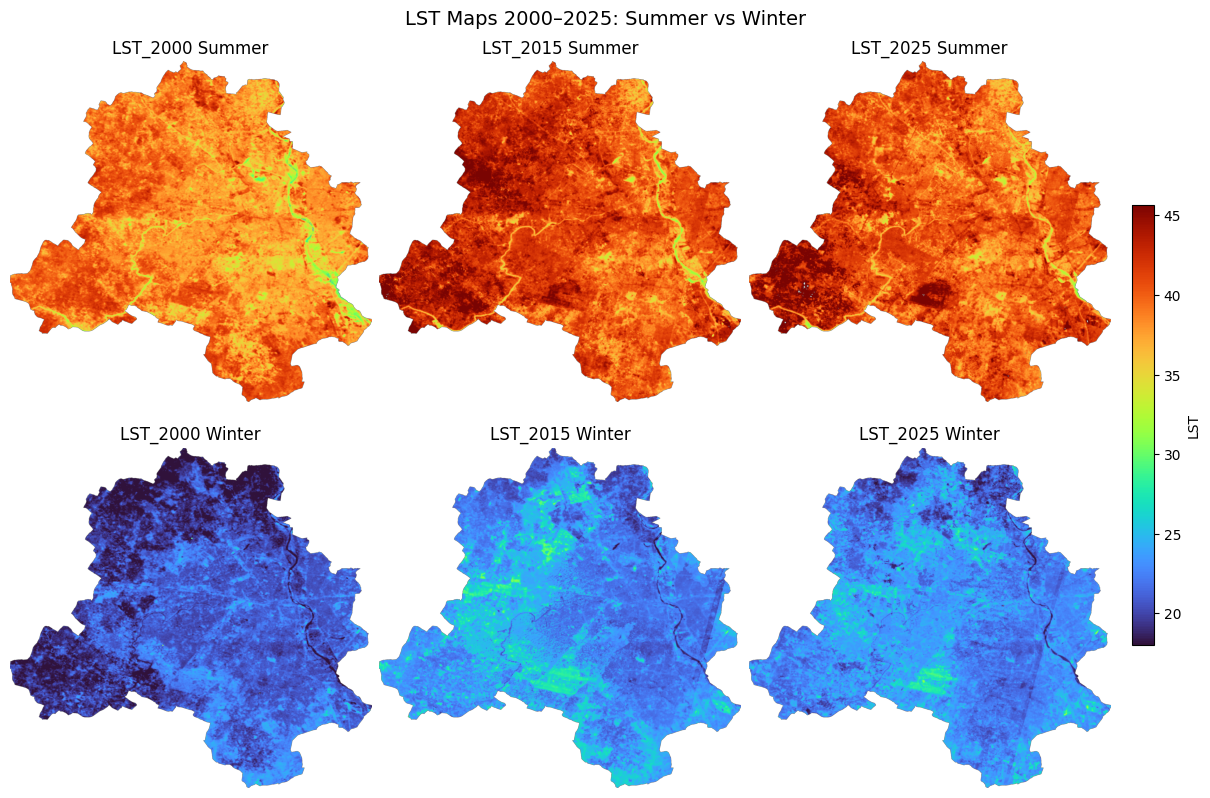

In [ ]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) Load all LST rasters
# --------------------------------------------------
lst_files = sorted(glob.glob(os.path.join(data_path, "LST_*.tif")))

summer_maps = []
winter_maps = []
summer_titles = []
winter_titles = []

# Load rasters and separate by season
for f in lst_files:
    arr, _ = load_raster(f)

    year = re.search(r"(\d{4})", os.path.basename(f)).group(1)
    title = f"LST_{year}"

    if "summer" in f.lower():
        summer_maps.append(arr)
        summer_titles.append(title + " Summer")
    else:
        winter_maps.append(arr)
        winter_titles.append(title + " Winter")

# --------------------------------------------------
# 2) Use identical min–max scale across all maps
# --------------------------------------------------
all_data = summer_maps + winter_maps
vmin = np.nanmin([np.nanmin(m) for m in all_data])
vmax = np.nanmax([np.nanmax(m) for m in all_data])
vmin, vmax = np.nanpercentile(np.concatenate([m.ravel() for m in all_data]), [1, 99])


# --------------------------------------------------
# 3) Create figure with Summer (top) and Winter (bottom)
# --------------------------------------------------
ncols = max(len(summer_maps), len(winter_maps))
fig, axes = plt.subplots(2, ncols, figsize=(4*ncols, 8),
                         constrained_layout=True)

# Plot Summer row
for i in range(ncols):
    if i < len(summer_maps):
        im = axes[0, i].imshow(summer_maps[i], vmin=vmin, vmax=vmax, cmap="turbo")
        axes[0, i].set_title(summer_titles[i])
        axes[0, i].axis("off")
    else:
        axes[0, i].axis("off")

# Plot Winter row
for i in range(ncols):
    if i < len(winter_maps):
        axes[1, i].imshow(winter_maps[i], vmin=vmin, vmax=vmax, cmap="turbo")
        axes[1, i].set_title(winter_titles[i])
        axes[1, i].axis("off")
    else:
        axes[1, i].axis("off")

# --------------------------------------------------
# 4) Add ONE common colorbar
# --------------------------------------------------
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("LST")

fig.suptitle("LST Maps 2000–2025: Summer vs Winter", fontsize=14)

# --------------------------------------------------
# 5) Export as PNG (and PDF)
# --------------------------------------------------
png_path = os.path.join(data_path, "LST_maps_summer_winter.png")
pdf_path = os.path.join(data_path, "LST_maps_summer_winter.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()
